In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import dataset
import network
import train_network

In [3]:
device = 'cpu'
network_shape = [3, 100, 100, 100, 2]
scheduler = train_network.Scheduler()
device

'cpu'

In [4]:
net = network.Network(network_shape, scheduler).to(device)
checkpoint = torch.load('network_final.pt', map_location=device)
net.load_state_dict(checkpoint['weights'])

<All keys matched successfully>

In [5]:
n=100
pts = net.sample(n,0,'cpu') # use 0 for DDIM and 1 for DDPM
pts.shape

(100, 2, 1001)

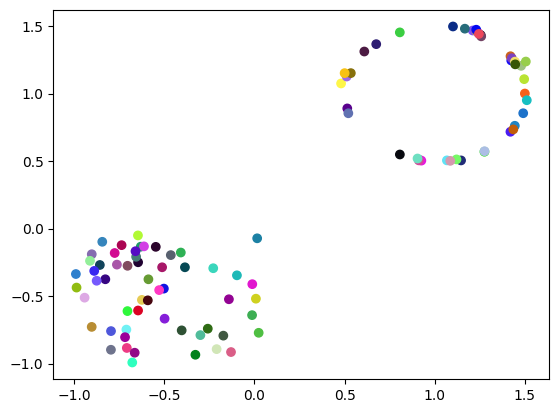

In [6]:
t = 1
colors = np.random.uniform(0,1,[n,3])
plt.scatter(pts[:,0,t],pts[:,1,t],c=colors)
plt.show()

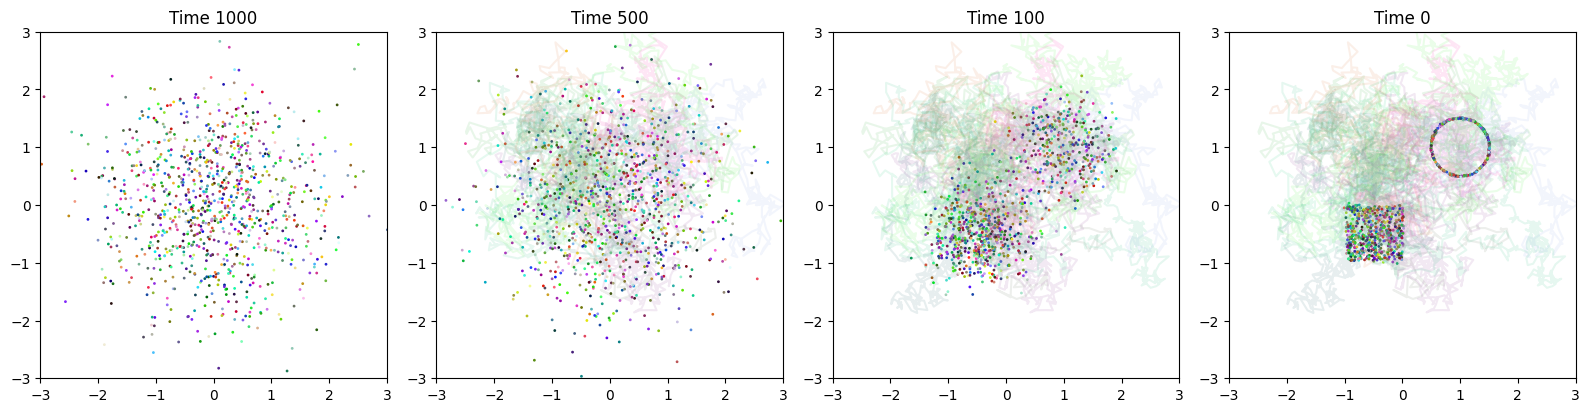

In [10]:
# Sampling with DDPM
times = [1000,500,100,0]
n=1000
pts = net.sample(n,1,'cpu')
colors = np.random.uniform(0,1,[n,3])

fig, axes = plt.subplots(1, len(times), figsize=(16, 4))

for i, ax in enumerate(axes):
    ax.scatter(pts[:,0,times[i]],pts[:,1,times[i]],c=colors, s=1)
    ax.set_ylim([-3, 3])
    ax.set_xlim([-3, 3])
    ax.set_aspect('equal')
    ax.set_title(f"Time {times[i]}")
    
num_trajectories = 10
for i, ax in enumerate(axes):
    for k in range(num_trajectories):
        ax.plot(pts[k,0,times[i]:],pts[k,1,times[i]:],c=colors[k,:],alpha=0.1)

plt.tight_layout()
plt.show()
fig.savefig("ddpm_vis.jpg")

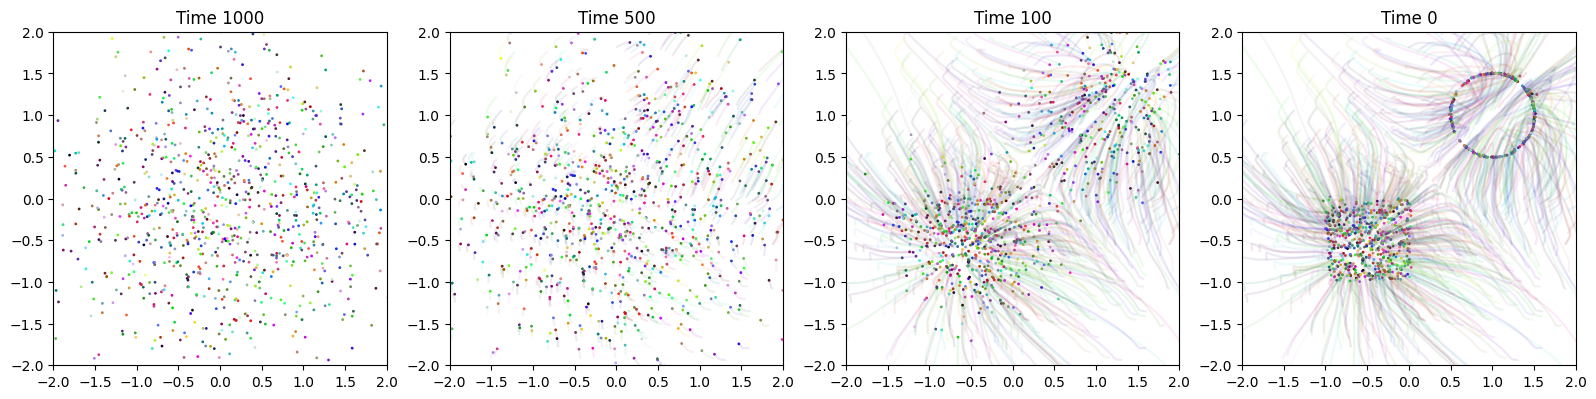

In [9]:
# Sampling with DDIM
times = [1000,500,100,0]
n=1000
pts = net.sample(n,0,'cpu')
colors = np.random.uniform(0,1,[n,3])

fig, axes = plt.subplots(1, len(times), figsize=(16, 4))

for i, ax in enumerate(axes):
    ax.scatter(pts[:,0,times[i]],pts[:,1,times[i]],c=colors, s=1)
    ax.set_ylim([-2, 2])
    ax.set_xlim([-2, 2])
    ax.set_aspect('equal')
    ax.set_title(f"Time {times[i]}")

num_trajectories = 1000
for i, ax in enumerate(axes):
    for k in range(num_trajectories):
        ax.plot(pts[k,0,times[i]:],pts[k,1,times[i]:],c=colors[k,:],alpha = 0.1)

plt.tight_layout()
plt.show()
fig.savefig("ddim_vis.jpg")